# Assignment 7: Consensus and Forks Lab


## 1. Setup

In [1]:
from __future__ import annotations

import argparse
import hashlib
import heapq
import json
import math
import os
import random
import time
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Callable, Dict, Iterable, List, Optional, Tuple

BLOCK_REWARD = 50          # coinbase units (not rand)
DEFAULT_BITS = 12          # leading zero bits; ~4 096 hashes per block on average
RESULTS_DIR = os.path.join(os.getcwd(), "results")

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Primitives: transactions, blocks and proof of work
`Tx` is a UTXO-lite transaction (inputs are coin ids `txid:index`). `Block` carries a Merkle root, a double-SHA-256 header and real proof of work at low difficulty (12 leading zero bits, about 4 096 hashes). Work per block is $2^{bits}$, the expected number of hashes, which is what the heaviest-work rule sums.

In [2]:
def sha256d(data: bytes) -> str:
    return hashlib.sha256(hashlib.sha256(data).digest()).hexdigest()


@dataclass(frozen=True)
class Tx:
    """UTXO-lite transaction. inputs are coin ids "<txid>:<index>"."""
    inputs: Tuple[str, ...]
    outputs: Tuple[Tuple[str, int], ...]      # (owner, amount)
    memo: str = ""

    @property
    def txid(self) -> str:
        body = json.dumps([list(self.inputs), [list(o) for o in self.outputs], self.memo])
        return sha256d(body.encode())[:16]

    @property
    def is_coinbase(self) -> bool:
        return len(self.inputs) == 0

    def size(self) -> int:
        return 60 + 40 * len(self.inputs) + 34 * len(self.outputs)


def merkle_root(txids: List[str]) -> str:
    layer = list(txids) or [""]
    while len(layer) > 1:
        if len(layer) % 2:
            layer.append(layer[-1])
        layer = [sha256d((layer[i] + layer[i + 1]).encode()) for i in range(0, len(layer), 2)]
    return sha256d(layer[0].encode())


@dataclass
class Block:
    height: int
    prev_hash: str
    miner: str
    txs: Tuple[Tx, ...]
    bits: int
    timestamp: float
    nonce: int = 0
    payload_bytes: int = 0          # padding to simulate a large block on the wire
    hash: str = ""

    def header(self) -> bytes:
        return json.dumps([self.height, self.prev_hash, merkle_root([t.txid for t in self.txs]),
                           self.bits, round(self.timestamp, 6), self.miner, self.nonce]).encode()

    def compute_hash(self) -> str:
        return sha256d(self.header())

    @property
    def target(self) -> int:
        return 2 ** (256 - self.bits)

    @property
    def work(self) -> int:
        """Expected number of hashes to find this block (2**bits)."""
        return 2 ** self.bits

    def pow_ok(self) -> bool:
        return self.hash == self.compute_hash() and int(self.hash, 16) < self.target

    def size(self) -> int:
        return 80 + sum(t.size() for t in self.txs) + self.payload_bytes


def make_genesis(allocations: Optional[Dict[str, int]] = None) -> Block:
    allocations = allocations or {"attacker": 10_000, "alice": 5_000, "bob": 5_000}
    tx = Tx((), tuple(sorted(allocations.items())), "genesis")
    g = Block(0, "0" * 64, "genesis", (tx,), bits=0, timestamp=0.0)
    g.hash = g.compute_hash()
    return g


def mine(prev: Block, miner: str, txs: Iterable[Tx], bits: int, timestamp: float,
         payload_bytes: int = 0, max_tries: int = 50_000_000) -> Block:
    height = prev.height + 1
    coinbase = Tx((), ((miner, BLOCK_REWARD),), f"coinbase:{height}:{miner}:{prev.hash[:12]}")
    b = Block(height, prev.hash, miner, (coinbase, *txs), bits, timestamp, 0, payload_bytes)
    target = b.target
    for nonce in range(max_tries):
        b.nonce = nonce
        h = b.compute_hash()
        if int(h, 16) < target:
            b.hash = h
            return b
    raise RuntimeError("mining failed; lower bits")

## 3. Ledger validation
A branch is only accepted if every block on it is valid against the UTXO set of its own parent: no missing or double-spent inputs, no value creation, coinbase capped at subsidy plus fees. This is what lets a reorganisation genuinely *reverse* a payment.

In [3]:
class InvalidBlock(Exception):
    pass


def apply_block(utxo: Dict[str, Tuple[str, int]], block: Block) -> Dict[str, Tuple[str, int]]:
    """Return the UTXO set after block, or raise InvalidBlock."""
    new = dict(utxo)
    fees = 0
    for i, tx in enumerate(block.txs):
        if tx.is_coinbase:
            if i != 0 and block.height != 0:
                raise InvalidBlock("coinbase not first")
            continue
        total_in = 0
        for cid in tx.inputs:
            if cid not in new:
                raise InvalidBlock(f"tx {tx.txid} spends missing/spent coin {cid}")
            total_in += new.pop(cid)[1]
        total_out = sum(a for _, a in tx.outputs)
        if total_out > total_in:
            raise InvalidBlock(f"tx {tx.txid} creates value")
        fees += total_in - total_out
        for j, out in enumerate(tx.outputs):
            new[f"{tx.txid}:{j}"] = out
    cb = block.txs[0]
    if block.height > 0:
        if not cb.is_coinbase or sum(a for _, a in cb.outputs) > BLOCK_REWARD + fees:
            raise InvalidBlock("bad coinbase")
    for j, out in enumerate(cb.outputs):
        new[f"{cb.txid}:{j}"] = out
    return new

## 4. Node: block tree, orphan pool and fork choice
Each node stores every valid block it has seen (a tree, not a list), cumulative work per block and an orphan pool for blocks whose parent has not arrived.
* **Fork choice:** `length` (longest chain) is the default and the rule used in the main experiments. `work` (heaviest cumulative work) is available for the extension in 6.4. With a fixed difficulty, as in every scenario except 6.4, the two rules pick the same chain.
* **Tie-break:** `first_seen` (Bitcoin Core), `lowest_hash`, `random`.
* **Reorg:** disconnects the old branch, connects the new one, returns still-valid transactions to the mempool and flags conflicting ones as reversed.

In [4]:
class Node:
    def __init__(self, name: str, genesis: Block, rule: str = "length",
                 tie_break: str = "first_seen", seed: int = 0,
                 labeler: Optional[Callable[[str], str]] = None):
        assert rule in ("work", "length") and tie_break in ("first_seen", "lowest_hash", "random")
        self.name, self.rule, self.tie_break = name, rule, tie_break
        self.rng = random.Random(seed)
        self.label = labeler or (lambda h: h[:8])
        self.blocks: Dict[str, Block] = {genesis.hash: genesis}
        self.cum_work: Dict[str, int] = {genesis.hash: genesis.work}
        self.utxo: Dict[str, Dict] = {genesis.hash: apply_block({}, genesis)}
        self.first_seen: Dict[str, float] = {genesis.hash: 0.0}
        self.orphans: Dict[str, List[Block]] = defaultdict(list)
        self.mempool: Dict[str, Tx] = {}
        self.tip = genesis.hash
        self.genesis = genesis.hash
        self.log: List[Tuple[float, str]] = []
        self.reorgs: List[dict] = []
        self.conflicted: List[str] = []           # txids reversed by a reorg and now invalid

    # ---------- chain helpers ----------
    def score(self, h: str) -> int:
        return self.cum_work[h] if self.rule == "work" else self.blocks[h].height

    def path(self, h: str) -> List[str]:
        out = []
        while True:
            out.append(h)
            if h == self.genesis:
                return out[::-1]
            h = self.blocks[h].prev_hash

    def main_chain(self) -> List[str]:
        return self.path(self.tip)

    def height(self) -> int:
        return self.blocks[self.tip].height

    def confirmations(self, txid: str) -> int:
        for h in reversed(self.main_chain()):
            if any(t.txid == txid for t in self.blocks[h].txs):
                return self.height() - self.blocks[h].height + 1
        return 0

    def balance(self, owner: str) -> int:
        return sum(a for o, a in self.utxo[self.tip].values() if o == owner)

    def _log(self, t: float, msg: str) -> None:
        self.log.append((t, msg))

    # ---------- mempool ----------
    def add_tx(self, tx: Tx) -> bool:
        spent = {c for m in self.mempool.values() for c in m.inputs}
        if any(c not in self.utxo[self.tip] or c in spent for c in tx.inputs):
            return False
        self.mempool[tx.txid] = tx
        return True

    def _prune_mempool(self) -> None:
        utxo = self.utxo[self.tip]
        in_chain = {t.txid for h in self.main_chain() for t in self.blocks[h].txs}
        self.mempool = {k: v for k, v in self.mempool.items()
                        if k not in in_chain and all(c in utxo for c in v.inputs)}

    # ---------- block processing ----------
    def receive(self, block: Block, t: float = 0.0, src: Optional[str] = None) -> List[Block]:
        """Process one block. Returns every block newly attached to the tree
        (the block itself plus any orphans it unlocked) so the caller can relay."""
        accepted, stack = [], [block]
        while stack:
            b = stack.pop()
            if self._accept_one(b, t, src):
                accepted.append(b)
                stack.extend(self.orphans.pop(b.hash, []))
        return accepted

    def _accept_one(self, b: Block, t: float, src: Optional[str]) -> bool:
        lab = self.label(b.hash)
        if b.hash in self.blocks:
            return False
        if not b.pow_ok():
            self._log(t, f"REJECT {lab}: invalid proof of work")
            return False
        if b.prev_hash not in self.blocks:
            if all(o.hash != b.hash for o in self.orphans[b.prev_hash]):
                self.orphans[b.prev_hash].append(b)
                self._log(t, f"ORPHAN {lab} (h={b.height}) from {src}: parent "
                             f"{self.label(b.prev_hash)} unknown, parked in orphan pool")
            return False
        parent = self.blocks[b.prev_hash]
        if b.height != parent.height + 1:
            self._log(t, f"REJECT {lab}: bad height")
            return False
        try:
            self.utxo[b.hash] = apply_block(self.utxo[parent.hash], b)
        except InvalidBlock as e:
            self._log(t, f"REJECT {lab}: {e}")
            return False
        self.blocks[b.hash] = b
        self.cum_work[b.hash] = self.cum_work[parent.hash] + b.work
        self.first_seen[b.hash] = t
        self._update_tip(b.hash, t, src)
        return True

    def _update_tip(self, h: str, t: float, src: Optional[str]) -> None:
        new, cur = self.score(h), self.score(self.tip)
        lab, tiplab = self.label(h), self.label(self.tip)
        if new > cur:
            self._switch(h, t)
        elif new == cur and h != self.tip:
            switch = (self.tie_break == "lowest_hash" and int(h, 16) < int(self.tip, 16)) or \
                     (self.tie_break == "random" and self.rng.random() < 0.5)
            self._log(t, f"TIE {lab} vs tip {tiplab} (score {new}); rule={self.tie_break} -> "
                         f"{'switch' if switch else 'keep ' + tiplab}")
            if switch:
                self._switch(h, t)
        else:
            self._log(t, f"STORE {lab} (h={self.blocks[h].height}) on side branch; tip stays {tiplab}")

    def _switch(self, h: str, t: float) -> None:
        old = self.tip
        if self.blocks[h].prev_hash == old:
            self.tip = h
            self._log(t, f"EXTEND tip -> {self.label(h)} (h={self.blocks[h].height})")
        else:
            old_path, new_path = self.path(old), self.path(h)
            k = 0
            while k < min(len(old_path), len(new_path)) and old_path[k] == new_path[k]:
                k += 1
            disconnected, connected = old_path[k:], new_path[k:]
            self.tip = h
            new_ids = {tx.txid for x in connected for tx in self.blocks[x].txs}
            utxo = self.utxo[h]
            back, reversed_ = [], []
            for x in disconnected:
                for tx in self.blocks[x].txs[1:]:
                    if tx.txid in new_ids:
                        continue
                    if all(c in utxo for c in tx.inputs):
                        self.mempool[tx.txid] = tx
                        back.append(tx.txid)
                    else:
                        reversed_.append(tx.txid)
                        self.conflicted.append(tx.txid)
            rec = dict(t=t, node=self.name, depth=len(disconnected),
                       fork_point=self.label(old_path[k - 1]),
                       disconnected=[self.label(x) for x in disconnected],
                       connected=[self.label(x) for x in connected],
                       txs_to_mempool=back, txs_reversed=reversed_)
            self.reorgs.append(rec)
            self._log(t, f"REORG depth {rec['depth']} at fork point {rec['fork_point']}: "
                         f"drop {rec['disconnected']} adopt {rec['connected']}"
                         + (f"; REVERSED txs {reversed_}" if reversed_ else ""))
        self._prune_mempool()

    # ---------- mining ----------
    def mine_block(self, t: float, txs: Optional[List[Tx]] = None, bits: int = DEFAULT_BITS,
                   payload_bytes: int = 0) -> Block:
        if txs is None:
            txs, spent, utxo = [], set(), self.utxo[self.tip]
            for tx in self.mempool.values():
                if all(c in utxo and c not in spent for c in tx.inputs):
                    txs.append(tx)
                    spent.update(tx.inputs)
        return mine(self.blocks[self.tip], self.name, txs, bits, t, payload_bytes)

    def summary(self) -> dict:
        return dict(node=self.name, tip=self.label(self.tip), height=self.height(),
                    cum_work=self.cum_work[self.tip],
                    chain=[self.label(h) for h in self.main_chain()],
                    known_blocks=len(self.blocks), orphans=sum(len(v) for v in self.orphans.values()),
                    reorgs=len(self.reorgs))

## 5. Network: discrete-event gossip
Deterministic event queue with per-link latency, optional bandwidth (large blocks arrive late), arbitrary topology, partitions and withheld messages delivered on heal. Every accepted block is relayed to all peers except its sender.

In [5]:
class Network:
    def __init__(self, names: List[str], genesis: Optional[Block] = None, latency: float = 1.0,
                 bandwidth: Optional[float] = None, rule: str = "length",
                 tie_break: str = "first_seen", links: Optional[List[Tuple[str, str]]] = None,
                 seed: int = 0, rules: Optional[Dict[str, str]] = None):
        self.genesis = genesis or make_genesis()
        self.labels: Dict[str, str] = {self.genesis.hash: "G"}
        lab = lambda h: self.labels.get(h, h[:6])
        rules = rules or {}
        self.nodes: Dict[str, Node] = {
            n: Node(n, self.genesis, rules.get(n, rule), tie_break, seed + i, lab)
            for i, n in enumerate(names)}
        pairs = links or [(a, b) for i, a in enumerate(names) for b in names[i + 1:]]
        self.links = {frozenset(p) for p in pairs}
        self.latency = {l: latency for l in self.links}
        self.bandwidth = bandwidth
        self.groups: Optional[List[set]] = None
        self.held: List[Tuple[str, str, Block]] = []
        self.q: list = []
        self.seq = 0
        self.now = 0.0

    # ---------- topology ----------
    def set_latency(self, a: str, b: str, sec: float) -> None:
        self.latency[frozenset((a, b))] = sec

    def neighbours(self, n: str) -> List[str]:
        return sorted(x for l in self.links if n in l for x in l if x != n)

    def partition(self, *groups: Iterable[str]) -> None:
        self.groups = [set(g) for g in groups]

    def heal(self) -> None:
        self.groups = None
        held, self.held = self.held, []
        for src, dst, b in held:
            self._send(src, dst, b)

    def _blocked(self, a: str, b: str) -> bool:
        return self.groups is not None and not any(a in g and b in g for g in self.groups)

    def delay(self, a: str, b: str, block: Block) -> float:
        d = self.latency[frozenset((a, b))]
        if self.bandwidth:
            d += block.size() / self.bandwidth
        return d

    # ---------- messaging ----------
    def _send(self, src: str, dst: str, block: Block) -> None:
        if self._blocked(src, dst):
            self.held.append((src, dst, block))
            return
        self.seq += 1
        heapq.heappush(self.q, (self.now + self.delay(src, dst, block), self.seq, src, dst, block))

    def broadcast(self, src: str, block: Block, exclude: Optional[str] = None) -> None:
        for peer in self.neighbours(src):
            if peer != exclude:
                self._send(src, peer, block)

    def name_block(self, b: Block, label: Optional[str] = None) -> str:
        base = label or f"{b.miner}{b.height}"
        lab, i = base, 1
        while lab in self.labels.values():
            i += 1
            lab = f"{base}.{i}"
        self.labels[b.hash] = lab
        return lab

    def mine(self, name: str, txs: Optional[List[Tx]] = None, bits: int = DEFAULT_BITS,
             payload_bytes: int = 0, broadcast: bool = True, label: Optional[str] = None) -> Block:
        node = self.nodes[name]
        b = node.mine_block(self.now, txs, bits, payload_bytes)
        self.name_block(b, label)
        node._log(self.now, f"MINED {self.labels[b.hash]} (h={b.height}, bits={b.bits})")
        node.receive(b, self.now, name)
        if broadcast:
            self.broadcast(name, b)
        return b

    def run(self, until: Optional[float] = None) -> None:
        while self.q and (until is None or self.q[0][0] <= until):
            t, _, src, dst, b = heapq.heappop(self.q)
            self.now = t
            for a in self.nodes[dst].receive(b, t, src):
                self.broadcast(dst, a, exclude=src)
        if until is not None:
            self.now = max(self.now, until)

    # ---------- reporting ----------
    def snapshot(self, tag: str = "") -> dict:
        return dict(tag=tag, t=round(self.now, 3),
                    nodes={n: nd.summary() for n, nd in self.nodes.items()},
                    converged=len({nd.tip for nd in self.nodes.values()}) == 1)

    def merged_log(self) -> List[str]:
        rows = [(t, n, m) for n, nd in self.nodes.items() for t, m in nd.log]
        rows.sort(key=lambda r: (r[0], r[1]))
        return [f"t={t:7.2f}s  {n}: {m}" for t, n, m in rows]


def print_snapshot(s: dict) -> None:
    print(f"\n[{s['tag']}] t={s['t']}s converged={s['converged']}")
    print(f"  {'node':<5}{'tip':<8}{'h':>3}{'work':>9}  main chain")
    for n, d in s["nodes"].items():
        print(f"  {n:<5}{d['tip']:<8}{d['height']:>3}{d['cum_work']:>9}  {' > '.join(d['chain'])}")

## 6. Scenarios (Part A)

### Scenario definitions
Each scenario returns snapshots and the merged event log; the next section runs them.

In [6]:
def scenario_fork(verbose: bool = True) -> dict:
    """(b) Two valid competing blocks at height 3, resolved by the next block."""
    net = Network(["A", "B", "C"], latency=1.0)
    net.set_latency("A", "C", 6.0)
    net.set_latency("B", "C", 3.0)
    net.mine("A"); net.run()
    net.mine("B"); net.run()
    snaps = [net.snapshot("common prefix")]
    net.mine("A")                      # A3
    net.mine("C")                      # C3, same instant, same parent: a fork
    net.run(until=net.now + 0.5)
    snaps.append(net.snapshot("fork created (before propagation)"))
    net.run()
    snaps.append(net.snapshot("after propagation: first-seen split"))
    net.mine("B")                      # B4 on top of A3
    net.run()
    snaps.append(net.snapshot("after B4: fork resolved"))
    out = dict(snapshots=snaps, log=net.merged_log(),
               reorgs=[r for nd in net.nodes.values() for r in nd.reorgs])
    if verbose:
        _print("SCENARIO 1: FORK AND LONGEST/HEAVIEST-CHAIN RESOLUTION", out)
    return out


def scenario_tie(verbose: bool = True) -> dict:
    """(c) Ties: equal-work competing tips under three tie-break policies."""
    results = {}
    for policy in ("first_seen", "lowest_hash", "random"):
        net = Network(["A", "B", "C"], latency=1.0, tie_break=policy, seed=11)
        net.set_latency("A", "C", 4.0)
        net.mine("B"); net.run()
        net.mine("A"); net.mine("C")
        net.run()
        s1 = net.snapshot(f"tie, policy={policy}")
        net.mine("B"); net.run()
        s2 = net.snapshot(f"after next block, policy={policy}")
        results[policy] = dict(during_tie=s1, after=s2, log=net.merged_log())
    if verbose:
        print("\n" + "=" * 78 + "\nSCENARIO 2: TIES\n" + "=" * 78)
        for p, r in results.items():
            print_snapshot(r["during_tie"]); print_snapshot(r["after"])
    return results


def scenario_delay(verbose: bool = True) -> dict:
    """(c) Delayed arrival: (i) child before parent (orphan pool) because a large
    block propagates slowly; (ii) partition, divergent mining, late delivery."""
    # (i) line topology A - B - C, bandwidth-limited links.
    net = Network(["A", "B", "C"], latency=0.5, bandwidth=50_000,
                  links=[("A", "B"), ("B", "C")])
    net.mine("A"); net.run()
    big = net.mine("A", payload_bytes=400_000, label="A2big")   # 8 s per hop
    net.run(until=net.now + 8.6)                                 # B has A2big, C does not
    net.mine("B", label="B3small")                               # small child, fast hop
    net.run()
    part1 = dict(snapshot=net.snapshot("out-of-order arrival resolved"), log=net.merged_log())

    # (ii) partition {A,B} | {C}
    net2 = Network(["A", "B", "C"], latency=1.0)
    net2.mine("A"); net2.run()
    net2.partition({"A", "B"}, {"C"})
    for m in ("A", "B", "A"):
        net2.mine(m); net2.run()
    for _ in range(2):
        net2.mine("C"); net2.run()
    split = net2.snapshot("during partition")
    net2.now += 30.0
    net2.heal(); net2.run()
    healed = net2.snapshot("after heal (late delivery)")
    part2 = dict(during=split, after=healed, log=net2.merged_log(),
                 reorgs=[r for nd in net2.nodes.values() for r in nd.reorgs])
    out = dict(out_of_order=part1, partition=part2)
    if verbose:
        print("\n" + "=" * 78 + "\nSCENARIO 3: DELAYED BLOCK ARRIVAL\n" + "=" * 78)
        print_snapshot(part1["snapshot"])
        for line in part1["log"]:
            if "ORPHAN" in line or "C:" in line:
                print("  " + line)
        print_snapshot(split); print_snapshot(healed)
        for r in part2["reorgs"]:
            print("  reorg:", r)
    return out


def scenario_heaviest(verbose: bool = True) -> dict:
    """Longest-chain vs heaviest-work: 3 easy blocks vs 2 hard blocks."""
    out = {}
    for rule in ("length", "work"):
        net = Network(["A", "B", "C"], latency=1.0, rule=rule)
        net.mine("B"); net.run()
        net.partition({"A"}, {"B", "C"})
        for _ in range(3):
            net.mine("A", bits=8); net.run()      # cheap branch: 3 x 2^8 = 768
        for _ in range(2):
            net.mine("C", bits=13); net.run()     # expensive branch: 2 x 2^13 = 16 384
        net.heal(); net.run()
        out[rule] = net.snapshot(f"rule={rule}")
    if verbose:
        print("\n" + "=" * 78 + "\nSCENARIO 4: LONGEST CHAIN vs HEAVIEST WORK\n" + "=" * 78)
        for s in out.values():
            print_snapshot(s)
    return out


def scenario_doublespend(z: int = 1, verbose: bool = True) -> dict:
    """R10 000 double-spend against a merchant who ships after z confirmations.
    Scripted: the attacker is assumed lucky enough to mine z+1 private blocks
    while the honest network mines z. Probabilities come from attacker_success()."""
    net = Network(["A", "B", "C"], latency=1.0)   # A honest miner, B merchant, C attacker
    A, B, C = (net.nodes[x] for x in "ABC")
    coin = next(cid for cid, (o, _) in A.utxo[A.tip].items() if o == "attacker")
    pay = Tx((coin,), (("merchant", 10_000),), "R10 000 purchase")
    back = Tx((coin,), (("attacker", 10_000),), "attacker refund to self")
    net.partition({"A", "B"}, {"C"})              # attacker mines in private from now
    net.mine("A", txs=[pay], label="A1pay")
    net.run()
    for _ in range(z - 1):
        net.mine("A"); net.run()
    shipped_at = B.confirmations(pay.txid)
    merchant_bal_before = B.balance("merchant")
    net.mine("C", txs=[back], label="C1dbl"); net.run()
    for _ in range(z):
        net.mine("C"); net.run()
    before = net.snapshot("merchant ships goods")
    net.heal(); net.run()
    after = net.snapshot("attacker releases private chain")
    out = dict(z=z, pay_txid=pay.txid, confirmations_when_shipped=shipped_at,
               merchant_balance_before=merchant_bal_before,
               merchant_balance_after=B.balance("merchant"),
               confirmations_after=B.confirmations(pay.txid),
               reversed_at_merchant=pay.txid in B.conflicted,
               before=before, after=after, reorgs=B.reorgs, log=net.merged_log())
    if verbose:
        print("\n" + "=" * 78 + f"\nSCENARIO 5: R10 000 DOUBLE-SPEND AGAINST z={z}\n" + "=" * 78)
        print_snapshot(before); print_snapshot(after)
        print(f"  merchant saw {shipped_at} conf(s), balance {merchant_bal_before} -> "
              f"{out['merchant_balance_after']}; payment reversed: {out['reversed_at_merchant']}")
    return out

## Analytics: confirmation depth and stale rate
* `nakamoto_success`: Nakamoto (2008) Poisson approximation.
* `rosenfeld_success`: Rosenfeld (2014) exact result (attacker holds one pre-mined block; conservative).
* `strict_success`: exact result without a pre-mined block.
* `attacker_success_mc`: Monte Carlo race used to check both.
* `simulate_stale_rate`: abstract 10-miner model used in Part B.

In [7]:
def nakamoto_success(q: float, z: int) -> float:
    """Nakamoto (2008) section 11: Poisson approximation of attacker progress."""
    p = 1.0 - q
    if q >= p:
        return 1.0
    lam = z * q / p
    s = 1.0
    for k in range(z + 1):
        poisson = math.exp(-lam) * lam ** k / math.factorial(k)
        s -= poisson * (1 - (q / p) ** (z - k))
    return max(0.0, s)


def rosenfeld_success(q: float, z: int) -> float:
    """Rosenfeld (2014) exact negative-binomial result (attacker must end strictly ahead)."""
    p = 1.0 - q
    if q >= p:
        return 1.0
    if z == 0:
        return 1.0
    s = 0.0
    for m in range(z + 1):
        s += math.comb(m + z - 1, m) * (p ** z * q ** m - p ** m * q ** z)
    return max(0.0, 1.0 - s)


def strict_success(q: float, z: int) -> float:
    """Exact success probability without a pre-mined block: the attacker starts on
    the parent of the payment block and must finish strictly ahead."""
    p = 1.0 - q
    if q >= p:
        return 1.0
    s = 0.0
    for m in range(z + 1):
        s += math.comb(m + z - 1, m) * p ** z * q ** m * (1 - (q / p) ** (z - m + 1))
    return max(0.0, 1.0 - s)


def attacker_success_mc(q: float, z: int, trials: int = 100_000, seed: int = 1,
                        give_up: int = 40, premine: int = 0) -> float:
    """Monte Carlo of the race. Each new block is the attacker's with prob q.
    premine=0: attacker starts on the parent of the payment block (strict model).
    premine=1: attacker already holds one private block (Rosenfeld's convention)."""
    rng = random.Random(seed)
    wins = 0
    for _ in range(trials):
        honest, att = 0, premine
        while honest < z:                         # merchant waits for z confirmations
            if rng.random() < q:
                att += 1
            else:
                honest += 1
        while True:                               # catch-up race (gambler's ruin)
            if att > honest:
                wins += 1
                break
            if honest - att > give_up:
                break
            if rng.random() < q:
                att += 1
            else:
                honest += 1
    return wins / trials


def required_depth(q: float, eps: float, zmax: int = 200) -> int:
    for z in range(1, zmax + 1):
        if rosenfeld_success(q, z) <= eps:
            return z
    return zmax


def simulate_stale_rate(block_interval: float, delay: float, n_miners: int = 10,
                        n_blocks: int = 20_000, seed: int = 0) -> float:
    """Abstract (no hashing) model used for Part B. Equal-power miners, uniform
    one-hop propagation delay; each miner mines on its first-seen highest tip."""
    rng = random.Random(seed)
    parent = {0: None}
    height = {0: 0}
    tip = [0] * n_miners
    pending: list = []
    t, nid = 0.0, 0
    for _ in range(n_blocks):
        t += rng.expovariate(1.0 / block_interval)
        while pending and pending[0][0] <= t:
            _, _, m, b = heapq.heappop(pending)
            if height[b] > height[tip[m]]:
                tip[m] = b
        m = rng.randrange(n_miners)
        nid += 1
        parent[nid], height[nid] = tip[m], height[tip[m]] + 1
        tip[m] = nid
        for o in range(n_miners):
            if o != m:
                heapq.heappush(pending, (t + delay, nid, o, nid))
    best = max(height, key=lambda b: (height[b], -b))
    main = 0
    while best is not None:
        main += 1
        best = parent[best]
    return 1.0 - (main - 1) / n_blocks

### Reporting helpers

In [8]:
def _print(title: str, out: dict) -> None:
    print("\n" + "=" * 78 + f"\n{title}\n" + "=" * 78)
    for s in out["snapshots"]:
        print_snapshot(s)
    print("\n  event log:")
    for line in out["log"]:
        print("  " + line)


def depth_table(verbose: bool = True) -> dict:
    qs, zs = (0.10, 0.20, 0.30), range(0, 11)
    rows = []
    for q in qs:
        for z in zs:
            rows.append(dict(q=q, z=z, nakamoto=nakamoto_success(q, z) if z else 1.0,
                             rosenfeld=rosenfeld_success(q, z),
                             mc_premine=attacker_success_mc(q, z, 20_000, seed=z, premine=1) if z else 1.0,
                             strict=strict_success(q, z) if z else 1.0,
                             mc_strict=attacker_success_mc(q, z, 20_000, seed=z) if z else 1.0))
    req = {q: {eps: required_depth(q, eps) for eps in (1e-2, 1e-3, 1e-4)} for q in qs}
    if verbose:
        print("\n" + "=" * 78 + "\nCONFIRMATION DEPTH: attacker success probability\n" + "=" * 78)
        print(f"  {'q':>5}{'z':>4}{'Nakamoto':>11}{'Rosenfeld':>11}{'MC(pre=1)':>11}"
              f"{'Strict':>11}{'MC(pre=0)':>11}")
        for r in rows:
            if r["z"] in (1, 2, 3, 6, 10):
                print(f"  {r['q']:>5}{r['z']:>4}{r['nakamoto']:>11.5f}{r['rosenfeld']:>11.5f}"
                      f"{r['mc_premine']:>11.5f}{r['strict']:>11.5f}{r['mc_strict']:>11.5f}")
        print("  required z (Rosenfeld):", req)
    return dict(rows=rows, required=req)


def _save(name: str, obj) -> None:
    os.makedirs(RESULTS_DIR, exist_ok=True)
    with open(os.path.join(RESULTS_DIR, f"{name}.json"), "w") as f:
        json.dump(obj, f, indent=2, default=str)

In [9]:
def snap_table(snaps):
    rows = []
    for s in snaps:
        rows.append({"stage": s["tag"], "t (s)": s["t"],
                     **{f"{n} tip": f"{d['tip']} (h={d['height']})" for n, d in s["nodes"].items()},
                     "converged": s["converged"]})
    return pd.DataFrame(rows)

### 6.1 Creating and resolving a fork
After a common prefix G, A1, B2, nodes A and C each mine a valid block on B2 at t = 19 s. Latencies are asymmetric (A-B 1 s, B-C 3 s, A-C 6 s), so B sees A3 first. Under first-seen each node keeps the block it saw first when an equal-work competitor arrives: A and B stay on A3, C on C3. When B mines B4 on A3, C's candidate chain is strictly longer (height 4 against 3), so under the longest-chain rule C reorganises and all three nodes converge. C3 becomes stale and its coinbase disappears.

In [10]:
fork = scenario_fork(verbose=False)
display(snap_table(fork["snapshots"]))
print("\n".join(fork["log"]))

,stage,t (s),A tip,B tip,C tip,converged
0,common prefix,19.0,B2 (h=2),B2 (h=2),B2 (h=2),True
1,fork created (before propagation),19.5,A3 (h=3),B2 (h=2),C3 (h=3),False
2,after propagation: first-seen split,29.0,A3 (h=3),A3 (h=3),C3 (h=3),False
3,after B4: fork resolved,38.0,B4 (h=4),B4 (h=4),B4 (h=4),True


t=   0.00s  A: MINED A1 (h=1, bits=12)
t=   0.00s  A: EXTEND tip -> A1 (h=1)
t=   1.00s  B: EXTEND tip -> A1 (h=1)
t=   4.00s  C: EXTEND tip -> A1 (h=1)
t=  10.00s  B: MINED B2 (h=2, bits=12)
t=  10.00s  B: EXTEND tip -> B2 (h=2)
t=  11.00s  A: EXTEND tip -> B2 (h=2)
t=  13.00s  C: EXTEND tip -> B2 (h=2)
t=  19.00s  A: MINED A3 (h=3, bits=12)
t=  19.00s  A: EXTEND tip -> A3 (h=3)
t=  19.00s  C: MINED C3 (h=3, bits=12)
t=  19.00s  C: EXTEND tip -> C3 (h=3)
t=  20.00s  B: EXTEND tip -> A3 (h=3)
t=  22.00s  B: TIE C3 vs tip A3 (score 3); rule=first_seen -> keep A3
t=  23.00s  A: TIE C3 vs tip A3 (score 3); rule=first_seen -> keep A3
t=  23.00s  C: TIE A3 vs tip C3 (score 3); rule=first_seen -> keep C3
t=  29.00s  B: MINED B4 (h=4, bits=12)
t=  29.00s  B: EXTEND tip -> B4 (h=4)
t=  30.00s  A: EXTEND tip -> B4 (h=4)
t=  32.00s  C: REORG depth 1 at fork point B2: drop ['C3'] adopt ['A3', 'B4']


### 6.2 Ties
A tie means two competing tips of equal length. The same fork (A2 vs C2 on B1) runs under three tie-break policies. First-seen keeps the network split until the next block; lowest-hash converges instantly but rewards a withholding miner who publishes only when its hash wins ties; random (Eyal and Sirer's 2014 suggestion against selfish mining) does not guarantee agreement: here A and B flipped to C2 while C flipped to A2.

In [11]:
tie = scenario_tie(verbose=False)
rows = []
for pol, r in tie.items():
    d = r["during_tie"]["nodes"]
    rows.append({"tie-break": pol, "tips during tie (A/B/C)": " / ".join(d[n]["tip"] for n in "ABC"),
                 "converged during tie": r["during_tie"]["converged"],
                 "tip after next block": r["after"]["nodes"]["A"]["tip"], "converged after": r["after"]["converged"]})
pd.DataFrame(rows)

,tie-break,tips during tie (A/B/C),converged during tie,tip after next block,converged after
0,first_seen,A2 / A2 / C2,False,B3,True
1,lowest_hash,A2 / A2 / A2,True,B3,True
2,random,C2 / C2 / A2,False,B3,True


### 6.3 Delayed and out-of-order arrival
**Child before parent.** On a line A-B-C with 50 kB/s links, A mines a 400 kB block (about 8 s per hop) and B then mines a small child. The child overtakes its parent, so C parks it in the orphan pool and connects both when the parent arrives.

**Partition and late delivery.** {A, B} mine three blocks while C mines two. On heal, C receives the heavier branch and reorganises two blocks deep; A and B store C's blocks as a side branch and do not move.

In [12]:
delay = scenario_delay(verbose=False)
print("Out-of-order arrival (node C):")
print("\n".join(l for l in delay["out_of_order"]["log"] if " C:" in l))
display(snap_table([delay["partition"]["during"], delay["partition"]["after"]]))
pd.DataFrame(delay["partition"]["reorgs"])

Out-of-order arrival (node C):
t=   1.01s  C: EXTEND tip -> A1 (h=1)
t=  10.11s  C: ORPHAN B3small (h=3) from B: parent A2big unknown, parked in orphan pool
t=  18.01s  C: EXTEND tip -> A2big (h=2)
t=  18.01s  C: EXTEND tip -> B3small (h=3)


,stage,t (s),A tip,B tip,C tip,converged
0,during partition,5.0,A4 (h=4),A4 (h=4),C3 (h=3),False
1,after heal (late delivery),37.0,A4 (h=4),A4 (h=4),A4 (h=4),True


,t,node,depth,fork_point,disconnected,connected,txs_to_mempool,txs_reversed
0,36.0,C,2,A1,"[C2, C3]","[A2, B3, A4]",[],[]


### 6.4 Extension: longest chain vs heaviest work
Branch A: three easy blocks (8 bits, work 768). Branch C: two hard blocks (13 bits, work 16 384). Counting blocks lets cheap blocks win; summing work does not, which is why Bitcoin compares chainwork. (Miners choose `bits` here to make the point; real rules fix difficulty by retargeting.)

In [13]:
heavy = scenario_heaviest(verbose=False)
display(snap_table(list(heavy.values())))

,stage,t (s),A tip,B tip,C tip,converged
0,rule=length,6.0,A4 (h=4),A4 (h=4),A4 (h=4),True
1,rule=work,6.0,C3 (h=3),C3 (h=3),C3 (h=3),True


### 6.5 R10 000 double-spend against a one-confirmation merchant
C (attacker) pays merchant B R10 000; honest miner A includes it. C secretly mines a conflicting refund-to-self on the parent and publishes a branch one block longer after the merchant ships. The attacker's luck is scripted here; its probability is quantified in Section 7.

In [14]:
ds = scenario_doublespend(z=1, verbose=False)
display(snap_table([ds["before"], ds["after"]]))
print(f"merchant saw {ds['confirmations_when_shipped']} confirmation(s); balance {ds['merchant_balance_before']} -> {ds['merchant_balance_after']}; reversed: {ds['reversed_at_merchant']}")
pd.DataFrame(ds["reorgs"])

,stage,t (s),A tip,B tip,C tip,converged
0,merchant ships goods,1.0,A1pay (h=1),A1pay (h=1),C2 (h=2),False
1,attacker releases private chain,3.0,C2 (h=2),C2 (h=2),C2 (h=2),True


merchant saw 1 confirmation(s); balance 10000 -> 0; reversed: True


,t,node,depth,fork_point,disconnected,connected,txs_to_mempool,txs_reversed
0,2.0,B,1,G,[A1pay],"[C1dbl, C2]",[],[6e607ffd089723cc]


## 7. Confirmation depth for a R10 000 payment
A payment has *z* confirmations at a node when its block is in that node's best chain with *z* - 1 blocks on top. Depth is local: during the fork in 6.1, a transaction only in C3 had one confirmation at C and zero at A and B.

In [15]:
dt = depth_table(verbose=False)
depth_df = pd.DataFrame(dt["rows"])
display(depth_df[depth_df.z.isin([1, 2, 3, 6, 10])].round(5))
pd.DataFrame(dt["required"]).rename_axis("eps").T.rename_axis("q")

,q,z,nakamoto,rosenfeld,mc_premine,strict,mc_strict
1,0.1,1,0.20459,0.20000,0.19625,0.03111,0.03380
2,0.1,2,0.05098,0.05600,0.05585,0.00951,0.00920
3,0.1,3,0.01317,0.01712,0.01565,0.00303,0.00270
6,0.1,6,0.00024,0.00059,0.00050,0.00011,0.00005
10,0.1,10,0.00000,0.00001,0.00000,0.00000,0.00000
12,0.2,1,0.41590,0.40000,0.40210,0.13000,0.12785
13,0.2,2,0.20393,0.20800,0.20635,0.07240,0.07190
14,0.2,3,0.10324,0.11584,0.11740,0.04168,0.04420
17,0.2,6,0.01425,0.02331,0.02235,0.00875,0.00830
21,0.2,10,0.00107,0.00316,0.00430,0.00121,0.00100


eps,0.0100,0.0010,0.0001
q,,,
0.1,4,6,8
0.2,8,13,18
0.3,20,32,44


### Figure settings and assumptions

In [16]:
import csv
import matplotlib
from matplotlib.patches import FancyBboxPatch

HERE = os.getcwd()
FIG = os.path.join(HERE, "figures")
RES = os.path.join(HERE, "results")
os.makedirs(FIG, exist_ok=True)
os.makedirs(RES, exist_ok=True)

plt.rcParams.update({"font.family": "DejaVu Serif", "font.size": 9, "axes.edgecolor": "black",
                     "axes.linewidth": 0.7, "axes.grid": True, "grid.color": "0.88",
                     "grid.linewidth": 0.5, "legend.frameon": False, "savefig.dpi": 220})

# Assumptions (edit here)
T_BTC = 600.0                     # Bitcoin target block interval, seconds
DW_MEDIAN, DW_MEAN, DW_P95 = 6.5, 12.6, 40.0   # Decker & Wattenhofer (2013) propagation stats
EPS = 1e-3                        # tolerated double-spend probability


def save(fig, name):
    fig.savefig(os.path.join(FIG, name), bbox_inches="tight")
    plt.show()

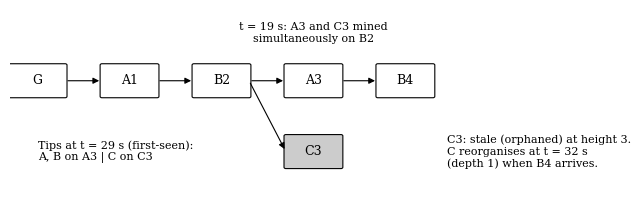

In [17]:
def fig_block_tree():
    fig, ax = plt.subplots(figsize=(7.0, 2.3))
    ax.set_xlim(-0.3, 5.6); ax.set_ylim(-1.5, 1.0); ax.axis("off")
    main = [("G", 0), ("A1", 1), ("B2", 2), ("A3", 3), ("B4", 4)]
    pos = {n: (x, 0) for n, x in main}
    pos["C3"] = (3, -1)

    def box(n, fc, hatch=None):
        x, y = pos[n]
        ax.add_patch(FancyBboxPatch((x - 0.3, y - 0.22), 0.6, 0.44, boxstyle="round,pad=0.02",
                                    fc=fc, ec="black", lw=0.8, hatch=hatch))
        ax.text(x, y, n, ha="center", va="center", fontsize=9)

    for n, _ in main:
        box(n, "white")
    box("C3", "0.8")
    for a, b in [("G", "A1"), ("A1", "B2"), ("B2", "A3"), ("A3", "B4"), ("B2", "C3")]:
        (x1, y1), (x2, y2) = pos[a], pos[b]
        ax.annotate("", xy=(x2 - 0.3, y2), xytext=(x1 + 0.3, y1),
                    arrowprops=dict(arrowstyle="-|>", lw=0.8, color="black"))
    ax.text(4.45, -1.0, "C3: stale (orphaned) at height 3.\nC reorganises at t = 32 s\n"
                        "(depth 1) when B4 arrives.", fontsize=8, va="center")
    ax.text(3.0, 0.55, "t = 19 s: A3 and C3 mined\nsimultaneously on B2", ha="center", fontsize=8)
    ax.text(0.0, -1.0, "Tips at t = 29 s (first-seen):\nA, B on A3 | C on C3", fontsize=8,
            va="center")
    save(fig, "fig1_block_tree.png")


# --------------------------------------------------------------------------- #
# Figure 2: attacker success vs confirmations

fig_block_tree()

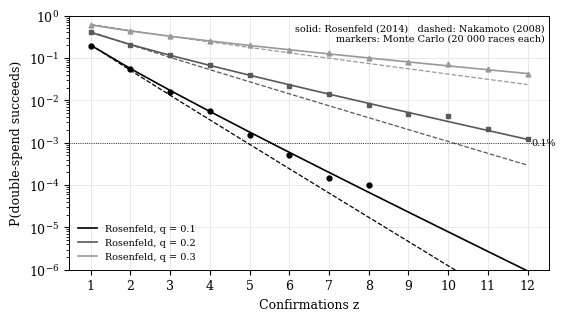

In [18]:
def fig_depth():
    rows = []
    fig, ax = plt.subplots(figsize=(6.2, 3.3))
    styles = {0.10: ("black", "o"), 0.20: ("0.35", "s"), 0.30: ("0.6", "^")}
    zs = list(range(1, 13))
    for q, (c, m) in styles.items():
        r = [rosenfeld_success(q, z) for z in zs]
        n = [nakamoto_success(q, z) for z in zs]
        mc = [attacker_success_mc(q, z, 20_000, seed=z, premine=1) for z in zs]
        s = [strict_success(q, z) for z in zs]
        ax.semilogy(zs, r, color=c, lw=1.2, label=f"Rosenfeld, q = {q:.1f}")
        ax.semilogy(zs, n, color=c, lw=0.9, ls="--")
        ax.semilogy([z for z, v in zip(zs, mc) if v > 0], [v for v in mc if v > 0], color=c, ls="none",
                    marker=m, ms=3.5)
        for z, a, b, d, e in zip(zs, r, n, mc, s):
            rows.append([q, z, round(b, 7), round(a, 7), round(d, 7), round(e, 7)])
    ax.axhline(EPS, color="black", lw=0.6, ls=":")
    ax.text(12.1, EPS, "0.1%", va="center", fontsize=7)
    ax.set_xlabel("Confirmations z"); ax.set_ylabel("P(double-spend succeeds)")
    ax.set_ylim(1e-6, 1); ax.set_xticks(zs)
    ax.legend(fontsize=7, loc="lower left")
    ax.text(0.99, 0.97, "solid: Rosenfeld (2014)   dashed: Nakamoto (2008)\nmarkers: Monte Carlo "
            "(20 000 races each)", transform=ax.transAxes, ha="right", va="top", fontsize=7)
    save(fig, "fig2_confirmation_depth.png")
    with open(os.path.join(RES, "depth_table.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["q", "z", "nakamoto", "rosenfeld_premine1", "mc_premine1", "strict_premine0"])
        w.writerows(rows)


# --------------------------------------------------------------------------- #
# Part B: relay time vs confirmation policy

fig_depth()

Nakamoto, Rosenfeld and Monte Carlo agree. Under Rosenfeld's conservative model, a 0.1% reversal bound needs 6 confirmations against an attacker with 10% of hash power, 13 at 20% and 32 at 30%.

**Why the answer is conditional.** Whether a payment is attacked cannot be determined by comparing R10 000 with the nominal block subsidy. Attack incentives can involve double-spending larger aggregate values in the same attack, external motives, rented hash power, capacity the attacker already operates, and other assumptions. The depth therefore depends on the attacker share *q* the institution assumes and the reversal probability it is willing to accept. The grid below makes those two inputs explicit.

**Conclusion.** For a R10 000-equivalent payment, confirmation depth should be selected according to the assumed attacker capability, observed network conditions, transaction value and the institution's acceptable reversal risk. Zero-confirmation acceptance provides the weakest protection, while additional confirmations progressively reduce reorganisation risk.

In [19]:
# Required depth z* (Rosenfeld) for each assumed attacker share q and tolerated reversal probability
qs = (0.05, 0.10, 0.15, 0.20, 0.25, 0.30)
eps_levels = (1e-2, 1e-3, 1e-4, 1e-5)
grid = pd.DataFrame({f"P < {e:.3%}": [required_depth(q, e) for q in qs] for e in eps_levels},
                    index=pd.Index([f"q = {q:.2f}" for q in qs], name="assumed attacker share"))
grid.to_csv(os.path.join(RES, "required_depth_grid.csv"))
grid

,P < 1.000%,P < 0.100%,P < 0.010%,P < 0.001%
assumed attacker share,,,,
q = 0.05,3,4,5,7
q = 0.10,4,6,8,10
q = 0.15,6,9,12,15
q = 0.20,8,13,18,23
q = 0.25,12,20,27,35
q = 0.30,20,32,44,57


## 8. Part B: block relay time vs confirmation policy
While a block propagates (relay time *d*), other miners still work on the old tip, so forks occur with probability about $f = 1 - e^{-d/T}$ (uniform-delay case of Decker and Wattenhofer, 2013), checked here by simulation. Honest work lost to forks raises the private attacker's effective share to $q_{eff} = q / (q + (1-q)(1-f))$. The policy depth $z^*$ is the smallest *z* with Rosenfeld success below 0.1%; expected wait is $z^*T/(1-f)$.

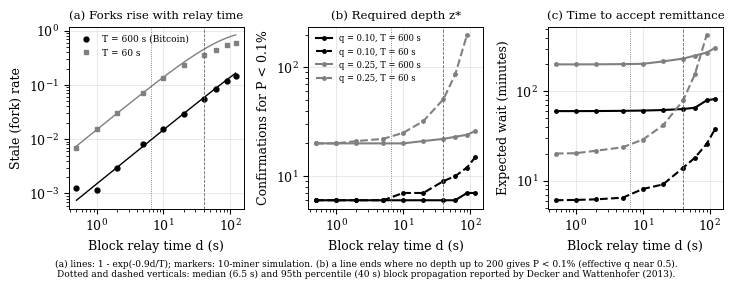

In [20]:
def stale_formula(d, T, n=10):
    return 1 - math.exp(-(1 - 1 / n) * d / T)


_SIM_CACHE = {}

def sim_stale(T, d):
    key = (T, d)
    if key not in _SIM_CACHE:
        _SIM_CACHE[key] = simulate_stale_rate(T, d, n_miners=10, n_blocks=12_000,
                                                 seed=int(d * 10) + int(T))
    return _SIM_CACHE[key]

def policy(q, d, T, eps=EPS, f=None):
    """Honest work lost to forks raises the attacker's effective share:
    q_eff = q / (q + p(1 - f)). Returns (f, q_eff, z*, expected wait in minutes);
    z* is None when q_eff >= 0.5 or no depth up to 200 meets eps."""
    f = (1 - math.exp(-d / T)) if f is None else f
    q_eff = q / (q + (1 - q) * (1 - f))
    if q_eff >= 0.5:
        return f, q_eff, None, None
    z = required_depth(q_eff, eps)
    if z >= 200:
        return f, q_eff, None, None
    return f, q_eff, z, z * T / (1 - f) / 60.0

def fig_relay():
    delays = [0.5, 1, 2, 5, 10, 20, 40, 60, 90, 120]
    rows = []
    fig, axs = plt.subplots(1, 3, figsize=(7.4, 2.7))
    ax = axs[0]
    for T, c, m, lab in [(600, "black", "o", "T = 600 s (Bitcoin)"), (60, "0.5", "s", "T = 60 s")]:
        sim = [sim_stale(T, d) for d in delays]
        xs = [x / 10 for x in range(5, 1201)]
        ax.loglog(xs, [stale_formula(x, T) for x in xs], color=c, lw=1)
        ax.loglog(delays, [max(v, 1e-4) for v in sim], color=c, marker=m, ls="none", ms=3.5, label=lab)
        for d, v in zip(delays, sim):
            rows.append(["stale", T, d, round(v, 5), round(stale_formula(d, T), 5), "", "", ""])
    ax.set_xlabel("Block relay time d (s)"); ax.set_ylabel("Stale (fork) rate")
    ax.set_title("(a) Forks rise with relay time", fontsize=8.5)
    ax.legend(fontsize=6.5, loc="upper left")

    for q, c in [(0.10, "black"), (0.25, "0.5")]:
        for T, ls in [(600, "-"), (60, "--")]:
            zs, ws = [], []
            for d in delays:
                f, qe, z, w = policy(q, d, T, f=sim_stale(T, d))
                zs.append(z if z is not None else float("nan"))
                ws.append(w if w is not None else float("nan"))
                rows.append(["policy", T, d, round(f, 5), "", q, z if z else "unsafe",
                             round(w, 1) if w else "unsafe"])
            axs[1].semilogx(delays, zs, color=c, ls=ls, marker="o", ms=2.5,
                            label=f"q = {q:.2f}, T = {int(T)} s")
            axs[2].semilogx(delays, ws, color=c, ls=ls, marker="o", ms=2.5)
    axs[1].set_yscale("log")
    axs[1].set_xlabel("Block relay time d (s)"); axs[1].set_ylabel("Confirmations for P < 0.1%")
    axs[1].set_title("(b) Required depth z*", fontsize=8.5)
    axs[1].legend(fontsize=6, loc="upper left")
    axs[2].set_yscale("log")
    axs[2].set_xlabel("Block relay time d (s)"); axs[2].set_ylabel("Expected wait (minutes)")
    axs[2].set_title("(c) Time to accept remittance", fontsize=8.5)
    for ax in axs:
        for x, ls in [(DW_MEDIAN, ":"), (DW_P95, "--")]:
            ax.axvline(x, color="0.4", lw=0.6, ls=ls)
    fig.text(0.5, -0.04, "(a) lines: 1 - exp(-0.9d/T); markers: 10-miner simulation. (b) a line ends where no depth "
             "up to 200 gives P < 0.1% (effective q near 0.5).\nDotted and dashed verticals: median "
             "(6.5 s) and 95th percentile (40 s) block propagation reported by Decker and Wattenhofer "
             "(2013).", ha="center", fontsize=6.5)
    fig.tight_layout()
    save(fig, "fig3_relay_vs_policy.png")
    with open(os.path.join(RES, "relay_policy.csv"), "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["kind", "T", "delay_s", "stale_sim_or_f", "stale_formula", "q", "z_req", "wait_min"])
        w.writerows(rows)

fig_relay()

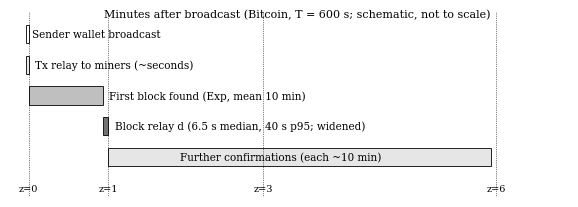

In [21]:
def fig_remittance_timeline():
    """Schematic: where relay time enters a remittance under each policy."""
    fig, ax = plt.subplots(figsize=(7.2, 2.4))
    ax.set_xlim(-2, 70); ax.set_ylim(-0.5, 4.6); ax.axis("off")
    lanes = [("Sender wallet broadcast", 0, 0.1, "white"),
             ("Tx relay to miners (~seconds)", 0.1, 0.4, "0.9"),
             ("First block found (Exp, mean 10 min)", 0.4, 10, "0.75"),
             ("Block relay d (6.5 s median, 40 s p95; widened)", 10, 10.7, "0.45"),
             ("Further confirmations (each ~10 min)", 10.7, 60, "0.9")]
    for i, (lab, a, b, fc) in enumerate(lanes):
        y = 4 - i * 0.85
        ax.add_patch(FancyBboxPatch((a, y - 0.25), max(b - a, 0.4), 0.5, boxstyle="square,pad=0",
                                    fc=fc, ec="black", lw=0.6))
        ax.text(-1.5, y, "", fontsize=7)
        ax.text(b + 0.8 if b < 50 else 20, y, lab, va="center", fontsize=7.5)
    for z, x in [(0, 0.4), (1, 10.7), (3, 30.7), (6, 60.7)]:
        ax.axvline(x, color="black", lw=0.5, ls=":")
        ax.text(x, -0.35, f"z={z}", ha="center", fontsize=7)
    ax.text(35, 4.45, "Minutes after broadcast (Bitcoin, T = 600 s; schematic, not to scale)", ha="center", fontsize=8)
    save(fig, "fig4_remittance_timeline.png")

fig_remittance_timeline()

**Reading the diagram.** For Bitcoin, *d/T* is small: moving from 5 s to 40 s relay raises the stale rate from about 0.8% to 5.4% but leaves $z^*$ at 6 for q = 0.1. On a 60-second chain the same change moves the stale rate from about 7% to 35% and, for q = 0.25, $z^*$ from 22 to 51; at longer delays no depth is safe. Faster blocks buy shorter waits only while relay stays well below *T*.

In [22]:
relay = pd.read_csv(os.path.join(RES, 'relay_policy.csv'))
relay[relay.kind == 'policy'].drop(columns=['kind', 'stale_formula'])

,T,delay_s,stale_sim_or_f,q,z_req,wait_min
20,600,0.5,0.00125,0.10,6,60.1
21,600,1.0,0.00117,0.10,6,60.1
22,600,2.0,0.00300,0.10,6,60.2
23,600,5.0,0.00817,0.10,6,60.5
24,600,10.0,0.01550,0.10,6,60.9
25,600,20.0,0.02858,0.10,6,61.8
26,600,40.0,0.05425,0.10,6,63.4
27,600,60.0,0.08392,0.10,6,65.5
28,600,90.0,0.11708,0.10,7,79.3
29,600,120.0,0.14867,0.10,7,82.2


## 9. Part C inputs: depth under stated assumptions

In [23]:
bands = [("< R1 000", 1e-2), ("R1 000 to R10 000", 1e-3),
         ("R10 000 to R100 000", 1e-4), ("> R100 000", 1e-5)]
pd.DataFrame([{"value band (ZAR)": b,
               "tolerated reversal probability (illustrative)": f"{e:.3%}",
               **{f"Bitcoin z* if q = {q:.2f}": required_depth(q, e) for q in (0.05, 0.10, 0.25)},
               "BFT chain": "1 committed block, if at most f of 3f + 1 validators are faulty"}
              for b, e in bands])

,value band (ZAR),tolerated reversal probability (illustrative),Bitcoin z* if q = 0.05,Bitcoin z* if q = 0.10,Bitcoin z* if q = 0.25,BFT chain
0,< R1 000,1.000%,3,4,12,"1 committed block, if at most f of 3f + 1 vali..."
1,R1 000 to R10 000,0.100%,4,6,20,"1 committed block, if at most f of 3f + 1 vali..."
2,R10 000 to R100 000,0.010%,5,8,27,"1 committed block, if at most f of 3f + 1 vali..."
3,> R100 000,0.001%,7,10,35,"1 committed block, if at most f of 3f + 1 vali..."
